In [29]:
import pandas as pd


df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv", parse_dates=["valid_time"])

gusts = df[df["has_gust"] == 1]

station_stats = (
    gusts.groupby(["station_id", "icao"])
         .size()
         .reset_index(name="gust_count")
         .sort_values("gust_count", ascending=False)
)

display(station_stats)

print(f"Number of stations : {station_stats.shape[0]}")
print(f"Total number of gusts : {station_stats['gust_count'].sum()}")

,station_id,icao,gust_count
16,60220,GMMI,1747
14,60200,GMFB,1100
1,60096,GSVO,891
21,60280,GMAG,861
2,60101,GMTT,776
6,60135,GMME,490
4,60115,GMFO,385
23,60338,GEML,382
5,60120,GMMP,314
15,60210,GMFK,214


Number of stations : 25
Total number of gusts : 8958


In [25]:
FILE = "../data/cleaned/AROME_METAR_merged_2021_2025.csv"

df = pd.read_csv(FILE)

gmmf = df[df["icao"] == "GMMF"].copy()

# Gust speed statistics
gust = gmmf["gust_speed_ms"]

print(f"Number of rows        : {len(gmmf):,}")
print(f"gust_speed_ms non-NaN : {gust.notna().sum():,}")
print(f"gust_speed_ms NaN     : {gust.isna().sum():,}")
print()

print(f"< 10 m/s  : {(gust < 10).sum():,}")
print(f">= 10 m/s : {(gust >= 10).sum():,}")
print()

if len(gust):
    print(f"Min : {gust.min():.2f} m/s")
    print(f"Max : {gust.max():.2f} m/s")

if (gust >= 10).any():
    print("\nExamples of gusts >= 10 m/s :")
    print(
        gmmf.loc[gmmf["gust_speed_ms"] >= 10,
               ["icao", "datetime", "gust_speed_ms"]]
        .head(10)
    )
else:
    print("\nNo gusts >= 10 m/s found.")

Number of rows        : 11,308
gust_speed_ms non-NaN : 0
gust_speed_ms NaN     : 11,308

< 10 m/s  : 0
>= 10 m/s : 0

Min : nan m/s
Max : nan m/s

No gusts >= 10 m/s found.


In [26]:
import pandas as pd

FILE = "../data/cleaned/AROME_METAR_merged_2021_2025.csv"

df = pd.read_csv(FILE)

# GMMF uniquement
gmmf = df[df["icao"] == "GMMF"].copy()

wind = pd.to_numeric(gmmf["wind_speed_ms"], errors="coerce")
gust = pd.to_numeric(gmmf["gust_speed_ms"], errors="coerce")

print(f"Number of rows : {len(gmmf):,}")
print()

print("Wind speed statistics :")
print(wind.describe())
print()

for threshold in [10, 12, 15, 20]:
    mask = wind >= threshold
    n = mask.sum()

    print(f"Wind >= {threshold:2d} m/s : {n:5d} observations")

    if n > 0:
        print(f"   with gust : {gust[mask].notna().sum():5d}")
        print(f"   without gust : {gust[mask].isna().sum():5d}")

print()

print("=== Suspect cases : wind >= 10 m/s but gust missing ===")

suspect = gmmf[(wind >= 10) & (gust.isna())]

print(f"{len(suspect)} observations")

if len(suspect):
    print(
        suspect[
            [
                "datetime",
                "wind_speed_ms",
                "gust_speed_ms",
                "wind_dir_deg",
                "station",
            ]
        ].head(20)
    )

Number of rows : 11,308

Wind speed statistics :
count    11303.000000
mean         2.738282
std          1.536933
min          0.000000
25%          1.500000
50%          2.600000
75%          3.600000
max         12.400000
Name: wind_speed_ms, dtype: float64

Wind >= 10 m/s :    13 observations
   with gust :     0
   without gust :    13
Wind >= 12 m/s :     1 observations
   with gust :     0
   without gust :     1
Wind >= 15 m/s :     0 observations
Wind >= 20 m/s :     0 observations

=== Suspect cases : wind >= 10 m/s but gust missing ===
13 observations
                   datetime  wind_speed_ms  gust_speed_ms  wind_dir_deg  \
2742    2021-01-08 12:00:00           12.4            NaN         220.0   
128859  2021-12-19 09:00:00           10.3            NaN         120.0   
146991  2022-01-29 00:00:00           10.8            NaN         140.0   
147444  2022-01-30 00:00:00           10.3            NaN         150.0   
147546  2022-01-30 06:00:00           11.3            Na

In [30]:
year_totals = (
    df.groupby(df["valid_time"].dt.year)
     .size()
)

display(year_totals)

valid_time
2021    132817
2022    160606
2023    183387
2024    196441
2025    121420
dtype: int64

In [31]:
year_stats = (
    df.groupby(df["valid_time"].dt.year)
      .agg(
          samples=("has_gust", "size"),
          gusts=("has_gust", "sum")
      )
)

year_stats["gust_rate_%"] = (
    100 * year_stats["gusts"] / year_stats["samples"]
)

display(year_stats)

,samples,gusts,gust_rate_%
valid_time,,,
2021,132817,1427,1.074411
2022,160606,1678,1.044793
2023,183387,1480,0.807036
2024,196441,2621,1.334243
2025,121420,1752,1.442925


In [32]:
pd.crosstab(
    df["icao"],
    df["valid_time"].dt.year
)

valid_time,2021,2022,2023,2024,2025
icao,,,,,
GEML,7177,8699,8615,8327,5497
GMAA,1470,1058,4817,6358,3598
GMAD,7202,8714,8594,8705,5506
GMAG,4437,5231,5805,8046,5110
GMAT,3860,4727,5784,5789,3713
GMFB,1106,4516,5543,8617,5539
GMFF,7176,8715,8508,8649,5541
GMFI,0,0,7069,8573,4269
GMFK,7176,8666,8514,8653,5519


In [33]:
station_period = (
    df.groupby("icao")
      .agg(
          start=("valid_time", "min"),
          end=("valid_time", "max"),
          samples=("valid_time", "size")
      )
)

display(station_period)

,start,end,samples
icao,,,
GEML,2021-01-01 00:00:00,2025-08-24 21:00:00,38315
GMAA,2021-01-01 09:00:00,2025-08-24 21:00:00,17301
GMAD,2021-01-01 01:00:00,2025-08-24 21:00:00,38721
GMAG,2021-01-01 06:00:00,2025-08-24 21:00:00,28629
GMAT,2021-01-01 06:00:00,2025-08-24 21:00:00,23873
GMFB,2021-06-03 13:00:00,2025-08-24 21:00:00,25321
GMFF,2021-01-01 00:00:00,2025-08-24 21:00:00,38589
GMFI,2023-03-01 00:00:00,2025-07-07 11:00:00,19911
GMFK,2021-01-01 00:00:00,2025-08-24 21:00:00,38528


In [34]:
df.groupby("icao")["elevation_m"].first().sort_values()

icao
GMMP       6.00
GSVO      10.00
GMTT      18.89
GMAA      27.12
GMTA      27.12
GEML      47.54
GMSL      50.00
GMMF      59.00
GMMC      61.87
GMML      63.09
GMAD      76.20
GMME      84.12
GMMI     128.02
GMMW     177.00
GMAT     199.03
GMMN     199.94
GMAG     341.00
GMFO     467.86
GMMX     467.86
GMMD     472.00
GMFM     576.07
GMFF     579.12
GMFK    1044.85
GMFB    1143.00
GMMZ    1153.05
GMFI        NaN
Name: elevation_m, dtype: float64

In [35]:
missing = (
    pd.DataFrame({
        "NaN count": df.isna().sum(),
        "NaN %": (df.isna().mean() * 100).round(3),
        "dtype": df.dtypes.astype(str)
    })
    .query("`NaN count` > 0")
    .sort_values("NaN count", ascending=False)
)

print(f"Dataset shape: {df.shape}\n")

if missing.empty:
    print("✅ No missing values found.")
else:
    display(missing)

Dataset shape: (794671, 54)



,NaN count,NaN %,dtype
metar_avwx_gust_ms,786611,98.986,float64
gust_speed_ms,785713,98.873,float64
metar_present_weather,763158,96.034,str
metar_slp_hpa,543501,68.393,float64
metar_clouds,518111,65.198,str
metar_ceiling_m,467212,58.793,float64
metar_wind_dir_deg,93472,11.762,float64
metar_visibility_m,54699,6.883,float64
station_name,19911,2.506,str
station_lon,19911,2.506,float64


In [36]:
df[df["icao"] == "GMFI"][
    [
        "station_id",
        "icao",
        "station_name",
        "station_lon",
        "station_lat",
        "elevation_m",
        "arome_lon",
        "arome_lat",
    ]
].drop_duplicates()

,station_id,icao,station_name,station_lon,station_lat,elevation_m,arome_lon,arome_lat
296754,60160,GMFI,NaN,NaN,NaN,NaN,-5.15,33.5


In [38]:
# After fix : 

import pandas as pd


df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv", parse_dates=["valid_time"])

df[df["icao"] == "GMFI"][
    [
        "station_id",
        "icao",
        "station_name",
        "station_lon",
        "station_lat",
        "elevation_m",
        "arome_lon",
        "arome_lat",
    ]
].drop_duplicates()

,station_id,icao,station_name,station_lon,station_lat,elevation_m,arome_lon,arome_lat
296754,60160,GMFI,NaN,-5.1529,33.5053,1664.0,-5.15,33.5


In [10]:
stats = (
    df.groupby("icao")[
        [
            "t2m",
            "rh2m",
            "arome_wind10_speed",
            "arome_wind950_speed",
            "pblh",
            "tke20m",
            "edr20m",
        ]
    ]
    .mean()
)

display(stats.round(2))

,t2m,rh2m,arome_wind10_speed,arome_wind950_speed,pblh,tke20m,edr20m
icao,,,,,,,
GEML,19.08,0.72,3.35,6.76,389.53,0.71,0.02
GMAA,20.09,0.70,3.69,4.92,322.26,0.40,0.01
GMAD,19.85,0.69,3.74,4.90,331.47,0.36,0.01
GMAG,20.85,0.60,3.83,5.64,492.77,0.57,0.01
GMAT,20.57,0.69,4.85,8.10,501.97,0.60,0.01
GMFB,18.75,0.39,3.67,3.23,1034.76,1.31,0.04
GMFF,18.45,0.60,3.14,3.31,464.53,0.35,0.01
GMFI,13.90,0.56,2.97,2.55,591.16,0.87,0.02
GMFK,20.56,0.33,3.14,3.01,1041.53,0.47,0.01


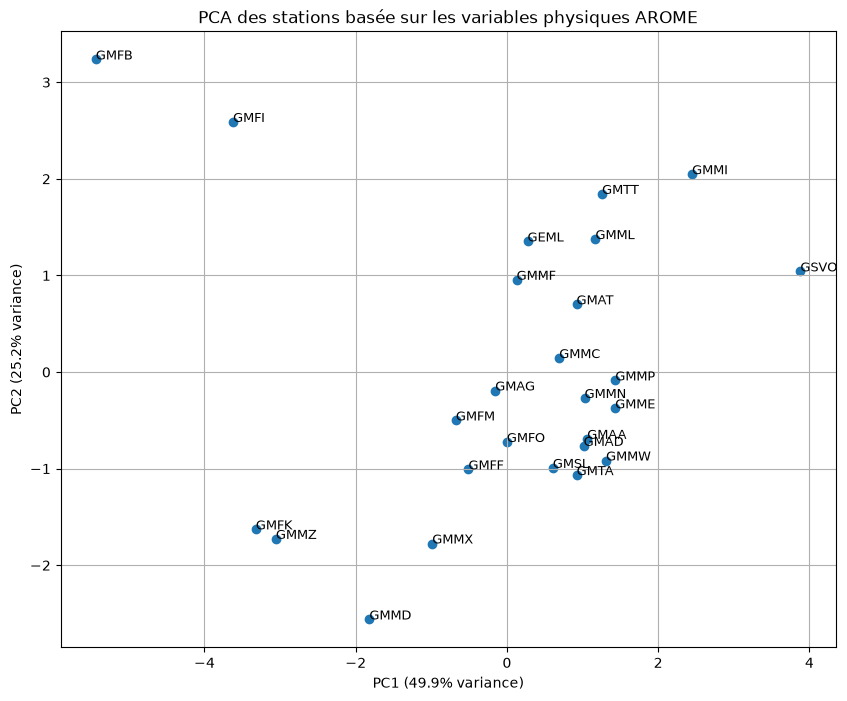

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA on AROME physical variables by station
features = [
    "t2m",
    "rh2m",
    "psurf",
    "arome_wind10_speed",
    "arome_wind950_speed",
    "pblh",
    "tke20m",
    "edr20m",
]

# One row per station with the mean of each feature
station_features = (
    df.groupby("icao")[features]
      .mean()
)

# Standardisation
X = StandardScaler().fit_transform(station_features)

# PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

pca_df = pd.DataFrame(
    coords,
    index=station_features.index,
    columns=["PC1", "PC2"]
)

# Plot PCA results
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for station, row in pca_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        station,
        fontsize=9
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)")
plt.title("PCA of AROME Physical Variables by Station")

plt.grid(True)
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

DATE_COL = "valid_time"
TARGET_COL = "has_gust"
STATION_COL = "station_id"

df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df[TARGET_COL] = df[TARGET_COL].astype(bool)

df = df[df["icao"] != "GSVO"]

df["year_month"] = df[DATE_COL].dt.to_period("M")

monthly_stats = (
    df.groupby("year_month")
    .agg(n_samples=(TARGET_COL, "size"), n_gusts=(TARGET_COL, "sum"))
    .assign(gust_rate_pct=lambda x: 100 * x.n_gusts / x.n_samples)
)

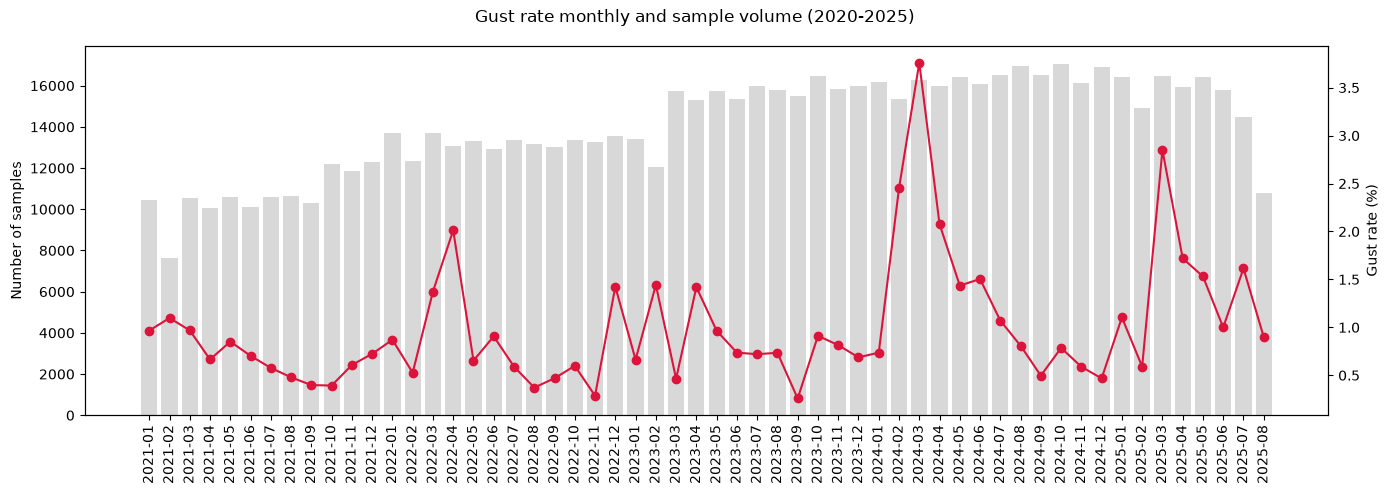

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly_stats.index.astype(str), monthly_stats.n_samples, alpha=0.3, color="gray", label="n_samples")
ax1.set_ylabel("Number of samples")
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly_stats.index.astype(str), monthly_stats.gust_rate_pct, color="crimson", marker="o", label="Gust rate (%)")
ax2.set_ylabel("Gust rate (%)")

fig.suptitle("Gust rate monthly and sample volume (2020-2025)")
fig.tight_layout()
plt.show()

In [1]:
from pathlib import Path
import pandas as pd

SPLIT_DIR = Path("../data/processed/splits")

train = pd.read_parquet(SPLIT_DIR / "train.parquet")
val = pd.read_parquet(SPLIT_DIR / "val.parquet")
test = pd.read_parquet(SPLIT_DIR / "test.parquet")

splits = {
    "train": train,
    "val": val,
    "test": test,
}

In [3]:
summary = []

total_samples = sum(len(df) for df in splits.values())

for name, df in splits.items():

    summary.append({
        "split": name,
        "samples": len(df),
        "% samples": 100 * len(df) / total_samples,
        "stations": df["icao"].nunique(),
        "gusts": int(df["has_gust"].sum()),
        "gust rate (%)": 100 * df["has_gust"].mean(),
        "start": df["run_time"].min().date(),
        "end": df["run_time"].max().date(),
    })

summary = pd.DataFrame(summary)

summary

,split,samples,% samples,stations,gusts,gust rate (%),start,end
0,train,476830,60.020291,26,4585,0.961559,2020-12-31,2023-12-31
1,val,196445,24.727232,26,2621,1.334216,2024-01-01,2024-12-31
2,test,121173,15.252477,25,1752,1.445867,2025-01-01,2025-08-24


In [8]:
stats = []

for name, df in splits.items():

    stats.append({
        "split": name,
        "No gust": int((df["has_gust"] == 0).sum()),
        "Gust": int((df["has_gust"] == 1).sum()),
        "Positive rate (%)": round(100 * df["has_gust"].mean(), 3),
    })

pd.DataFrame(stats)

,split,No gust,Gust,Positive rate (%)
0,train,472245,4585,0.962
1,val,193824,2621,1.334
2,test,119421,1752,1.446
